# Interpolación de _Lagrange_

$$
 f(x) = \sum_{k=1}^N y_k \prod_{j=0, j \neq k} \left(  \frac{x-x_j}{x_k - x_j }\right)
$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def lagrange_interp(x, xj, yj):
    assert xj.shape[0] == yj.shape[0]

    _n = xj.shape[0]
    f = 0.0
    for k in range(_n):
        poly = 1.0
        for j in range(_n):
            if j != k:
                poly *= (x-xj[j])/(xj[k] - xj[j])
        f += yj[k]*poly

    return f


In [ ]:
tk = np.array([0.0, 0.067, 0.1, 0.167, 0.2])
yk = np.array([1.5, 1.478, 1.451, 1.364, 1.305])

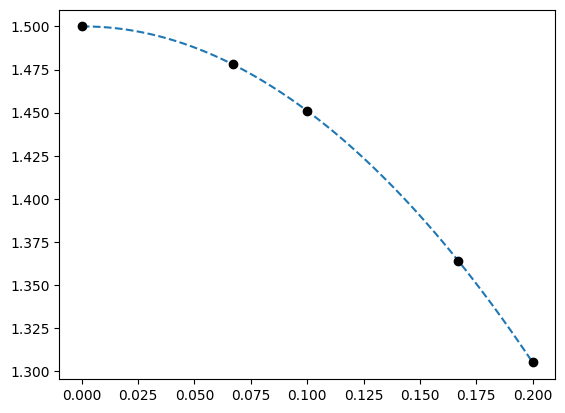

In [ ]:
t = np.linspace(0,0.2, 100)

def f(x):
    return lagrange_interp( x, tk, yk )

plt.plot( t, f(t), "--")
plt.plot(tk, yk, "ok")
plt.show()

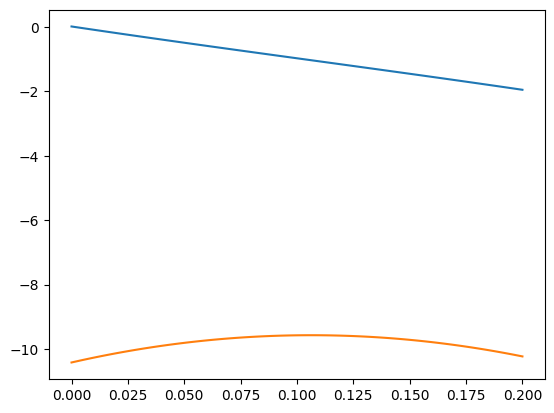

In [ ]:
tc = 0.133
h = 1e-4

v = lambda t: (f(t+h) - f(t-h))/(2*h)
a = lambda t: (v(t+h) - v(t-h))/(2*h)


plt.plot(t, v(t))
plt.plot(t, a(t))

**Ejercicio**:

Un proyectíl se lanza verticalmente desde una altura $y_0$. Durante el experimento se registran las siguientes posiciones

|t(s) | y(m) |
|---  | ---  |
| 0.0 | 1.0  |
| 0.2 | 2.76 |
| 0.4 | 4.13 |
| 0.6 | 5.12 |
| 0.8 | 5.73 |
| 1.0 | 5.96 |
| 1.2 | 5.81 |
| 1.4 | 5.28 |
| 1.6 | 4.37 |
| 1.8 | 3.08 |
| 2.0 | 1.41 |

Determinar el instante en el que el proyectíl alcanza la altura $y = 4.5$ m

Text(0, 0.5, 'y (m)')

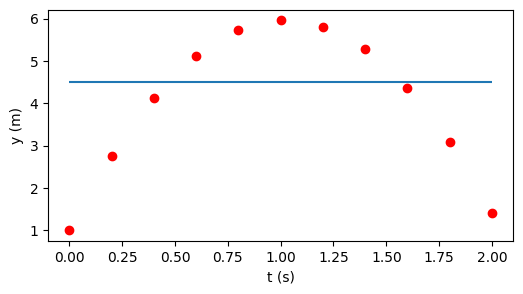

In [ ]:

tk = np.arange(0, 2.2, 0.2)
yk = np.array([1, 2.76, 4.13, 5.12, 5.73, 5.96, 5.81, 5.28, 4.37, 3.08, 1.41])

plt.figure(figsize=(6,3))
plt.plot(tk, yk, "or")
plt.hlines([4.5], 0, 2)
plt.xlabel("t (s)")
plt.ylabel("y (m)")

Text(0, 0.5, 'y (m)')

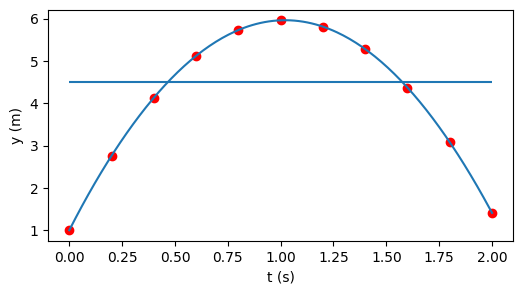

In [ ]:
f = lambda t: lagrange_interp(t, tk, yk)
t = np.linspace(0,2,200)

plt.figure(figsize=(6,3))
plt.plot(tk, yk, "or")
plt.plot(t,f(t), "-")
plt.hlines([4.5], 0, 2)
plt.xlabel("t (s)")
plt.ylabel("y (m)")

Problema a resolver

$$
    f(t) = 4.5 m
$$

resolver con NR, el siguiente problema de raíces

$$
    f(t) - 4.5 = 0
$$

In [ ]:
def newton_rhapson( f, fp, x0, tol = 1e-6, maxiter = 300 ):
    for i in range(maxiter):
        xn = x0 - f(x0)/fp(x0)

        if abs( xn - x0 ) < tol:
            return xn

        x0 = xn
    return x0


In [ ]:
F = lambda t: f(t) - 4.5
# velocidad
v = lambda t: (F(t+h) - F(t-h))/(2*h)

tc = newton_rhapson(F, v, 0.5)

In [ ]:
tc

np.float64(0.4662482959496298)

Text(0, 0.5, 'y (m)')

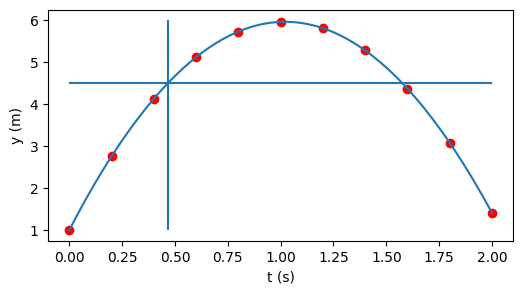

In [ ]:
plt.figure(figsize=(6,3))
plt.plot(tk, yk, "or")
plt.plot(t,f(t), "-")
plt.hlines([4.5], 0, 2)
plt.vlines([tc], 1, 6)
plt.xlabel("t (s)")
plt.ylabel("y (m)")